In [10]:
from langchain_groq import ChatGroq
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from IPython.display import Image, display 

In [ ]:
groq_api_key = "YOUR_GROQ_API_KEY"
llm = ChatGroq(groq_api_key = groq_api_key, model_name = "Gemma2-9b-it")

In [22]:
class State(TypedDict):
    messages:Annotated[list, add_messages] 
    sentiment: str 
    
def preprocess(state: State) -> State:
    cleaned = state['messages'][-1].content.strip() 
    state['messages'][-1].content = cleaned 
    return state 

def analyze_sentiment(state: State) -> State:
    msg = state["messages"][-1].content
    state["sentiment"] = 'positive' if 'good' in msg else 'neutral'
    return state

def chatbot(state: State) -> State:
    return {'messages': llm.invoke(state['messages'])}

def logger(state: State) -> State:
    print(f"LOG: {state['messages'][-1].content}, Sentiment: {state.get('sentiment')}")
    return state    
    
    

In [23]:
builder = StateGraph(State)
builder.add_node('preprocess', preprocess)
builder.add_node('analyze_sentiment', analyze_sentiment)
builder.add_node('chatbot',chatbot)
builder.add_node('logger', logger)

In [24]:
builder.add_edge(START,'preprocess')
builder.add_edge('preprocess','analyze_sentiment')
builder.add_edge('analyze_sentiment', 'chatbot')
builder.add_edge('chatbot', 'logger')
builder.add_edge('logger', END)

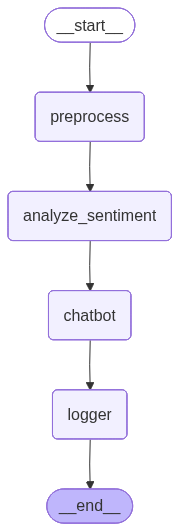

In [25]:
builder.compile()

In [26]:
graph = builder.compile()

In [28]:
input_message = 'This is likhith konda training programe'

final_state = graph.invoke({"messages": [("user", input_message)]})

print('Final state:', final_state)
print('chatbots response:', final_state['messages'][-1].content)
print('Detected sentiment:', final_state['sentiment'])


input_message_2 = 'This is neural message'

final_state_2 = graph.invoke({"messages": [("user", input_message_2)]})

print('Final state 2:', final_state_2)
print('chatbots response 2:', final_state_2['messages'][-1].content)
print('Detected sentiment 2:', final_state_2['sentiment'])

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}